## Dataset

1. We use the Bank Marketing Dataset from the UCI Machine Learning Repository.
Source: https://archive.ics.uci.edu/ml/datasets/bank+marketing

2. The data is related with direct marketing campaigns (phone calls) of a Portuguese banking institution. Originally designed for supervised learning, but we will ignore the label initially

Important Decision:

Even though the dataset contains subscribed (whether the client subscribed to a term deposit), we do not use it to train the clustering model.
We may, however, use it later for interpretation only.

    # bank client data:
    1 - age (numeric)
    2 - job : type of job (categorical: 'admin.','blue-collar','entrepreneur','housemaid','management','retired','self-employed','services','student','technician','unemployed','unknown')
    3 - marital : marital status (categorical: 'divorced','married','single','unknown'; note: 'divorced' means divorced or widowed)
    4 - education (categorical: 'basic.4y','basic.6y','basic.9y','high.school','illiterate','professional.course','university.degree','unknown')
    5 - default: has credit in default? (categorical: 'no','yes','unknown')
    6 - housing: has housing loan? (categorical: 'no','yes','unknown')
    7 - loan: has personal loan? (categorical: 'no','yes','unknown')
    # related with the last contact of the current campaign:
    8 - contact: contact communication type (categorical: 'cellular','telephone')
    9 - month: last contact month of year (categorical: 'jan', 'feb', 'mar', ..., 'nov', 'dec')
    10 - day_of_week: last contact day of the week (categorical: 'mon','tue','wed','thu','fri')
    11 - duration: last contact duration, in seconds (numeric). Important note: this attribute highly affects the output target (e.g., if duration=0 then y='no'). Yet, the duration is not known before a call is performed. Also, after the end of the call y is obviously known. Thus, this input should only be included for benchmark purposes and should be discarded if the intention is to have a realistic predictive model.
    # other attributes:
    12 - campaign: number of contacts performed during this campaign and for this client (numeric, includes last contact)
    13 - pdays: number of days that passed by after the client was last contacted from a previous campaign (numeric; 999 means client was not previously contacted)
    14 - previous: number of contacts performed before this campaign and for this client (numeric)
    15 - poutcome: outcome of the previous marketing campaign (categorical: 'failure','nonexistent','success')
    # social and economic context attributes
    16 - emp.var.rate: employment variation rate - quarterly indicator (numeric)
    17 - cons.price.idx: consumer price index - monthly indicator (numeric)
    18 - cons.conf.idx: consumer confidence index - monthly indicator (numeric)
    19 - euribor3m: euribor 3 month rate - daily indicator (numeric)
    20 - nr.employed: number of employees - quarterly indicator (numeric)
    21 - y - has the client subscribed a term deposit? (binary: 'yes','no')

## task 1

### Requirements

The goal of this lab is to **explore the bank dataset, prepare it for clustering, and apply K-Means**.  
Follow these steps carefully and write down your observations.  

### **Exploratory Data Analysis (EDA)** (understanding the dataset and its characteristics)

For each feature, you should:

- Identify **numeric vs categorical features**  
- Check **distributions** of numeric features (min, max, mean, std, skewness)  
- Check **counts of categories** for categorical features  
- Identify **missing or unknown values** and decide how to handle them  
- Look for **correlations** between numeric features  
- Identify **outliers** that may affect clustering  

In [27]:
import pandas as pd 
import matplotlib.pyplot as plt 
import numpy as np 
import seaborn as sns 
from sklearn.datasets import make_blobs 
from sklearn.cluster import KMeans 
import csv 
from sklearn.preprocessing import LabelEncoder
from sklearn import preprocessing

In [3]:
"""
| Numerical vs Categorical Variables
| Age, Balance, Day, Duration, Campaign, Pdays, Previous -- Numerical which means data represented in numbers
| Job, Martial, Education, Default, Housing, Loan, Contact, Month, poutcome , y -- Categorical which means data represented in categories

"""
bank = pd.read_csv('bank.csv', sep=';') 
pd.set_option('display.max_columns', None) 
bank.head(4)

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,30,unemployed,married,primary,no,1787,no,no,cellular,19,oct,79,1,-1,0,unknown,no
1,33,services,married,secondary,no,4789,yes,yes,cellular,11,may,220,1,339,4,failure,no
2,35,management,single,tertiary,no,1350,yes,no,cellular,16,apr,185,1,330,1,failure,no
3,30,management,married,tertiary,no,1476,yes,yes,unknown,3,jun,199,4,-1,0,unknown,no


In [4]:
"""
| Distribution of Numerical Variables

"""
bank.describe()

,age,balance,day,duration,campaign,pdays,previous
count,4521.000000,4521.000000,4521.000000,4521.000000,4521.000000,4521.000000,4521.000000
mean,41.170095,1422.657819,15.915284,263.961292,2.793630,39.766645,0.542579
std,10.576211,3009.638142,8.247667,259.856633,3.109807,100.121124,1.693562
min,19.000000,-3313.000000,1.000000,4.000000,1.000000,-1.000000,0.000000
25%,33.000000,69.000000,9.000000,104.000000,1.000000,-1.000000,0.000000
50%,39.000000,444.000000,16.000000,185.000000,2.000000,-1.000000,0.000000
75%,49.000000,1480.000000,21.000000,329.000000,3.000000,-1.000000,0.000000
max,87.000000,71188.000000,31.000000,3025.000000,50.000000,871.000000,25.000000


In [5]:
"""
| Counts of Categorical Variables

"""
job_counts = bank['job'].value_counts() 
print(job_counts)


job
management       969
blue-collar      946
technician       768
admin.           478
services         417
retired          230
self-employed    183
entrepreneur     168
unemployed       128
housemaid        112
student           84
unknown           38
Name: count, dtype: int64


In [6]:
martial_counts = bank['marital'].value_counts()
print(martial_counts)

marital
married     2797
single      1196
divorced     528
Name: count, dtype: int64


In [7]:
education_counts = bank['education'].value_counts()
print(education_counts)

education
secondary    2306
tertiary     1350
primary       678
unknown       187
Name: count, dtype: int64


In [8]:
default_counts = bank['default'].value_counts()
print(default_counts)

default
no     4445
yes      76
Name: count, dtype: int64


In [9]:
housing_counts = bank['housing'].value_counts()
print(housing_counts)

housing
yes    2559
no     1962
Name: count, dtype: int64


In [10]:
loan_counts = bank['loan'].value_counts()
print(loan_counts)

loan
no     3830
yes     691
Name: count, dtype: int64


In [11]:
contact_counts = bank['contact'].value_counts()
print(contact_counts)

contact
cellular     2896
unknown      1324
telephone     301
Name: count, dtype: int64


In [12]:
month_counts = bank['month'].value_counts()
print(month_counts)

month
may    1398
jul     706
aug     633
jun     531
nov     389
apr     293
feb     222
jan     148
oct      80
sep      52
mar      49
dec      20
Name: count, dtype: int64


In [13]:
outcome_counts = bank['poutcome'].value_counts()
print(outcome_counts)

poutcome
unknown    3705
failure     490
other       197
success     129
Name: count, dtype: int64


In [14]:
y_counts = bank['y'].value_counts()
print(y_counts)

y
no     4000
yes     521
Name: count, dtype: int64


In [18]:
""" 
| 'unknown' values in categorical variables indicate missing data.
| According to the dataset documentation, 'unknown' means that the information is not available for that particular entry.

"""
job_unknown = bank[bank['job'] == 'unknown'].shape[0] 
martial_unknown = bank[bank['marital'] == 'unknown'].shape[0]
education_unknown = bank[bank['education'] == 'unknown'].shape[0]
default_unknown = bank[bank['default'] == 'unknown'].shape[0]
housing_unknown = bank[bank['housing'] == 'unknown'].shape[0]
loan_unknown = bank[bank['loan'] == 'unknown'].shape[0]
contact_unknown = bank[bank['contact'] == 'unknown'].shape[0]
month_unknown = bank[bank['month'] == 'unknown'].shape[0]
outcome_unknown = bank[bank['poutcome'] == 'unknown'].shape[0]
y_unknown = bank[bank['y'] == 'unknown'].shape[0]

print(f"Number of 'unknown' values in 'job': {job_unknown}")
print(f"Number of 'unknown' values in 'marital': {martial_unknown}")
print(f"Number of 'unknown' values in 'education': {education_unknown}")
print(f"Number of 'unknown' values in 'default': {default_unknown}")
print(f"Number of 'unknown' values in 'housing': {housing_unknown}")
print(f"Number of 'unknown' values in 'loan': {loan_unknown}")
print(f"Number of 'unknown' values in 'contact': {contact_unknown}")
print(f"Number of 'unknown' values in 'month': {month_unknown}")    
print(f"Number of 'unknown' values in 'poutcome': {outcome_unknown}")
print(f"Number of 'unknown' values in 'y': {y_unknown}")

Number of 'unknown' values in 'job': 0
Number of 'unknown' values in 'marital': 0
Number of 'unknown' values in 'education': 0
Number of 'unknown' values in 'default': 0
Number of 'unknown' values in 'housing': 0
Number of 'unknown' values in 'loan': 0
Number of 'unknown' values in 'contact': 0
Number of 'unknown' values in 'month': 0
Number of 'unknown' values in 'poutcome': 0
Number of 'unknown' values in 'y': 0


In [16]:
""" 
| Missing Values 

"""
print(bank.isnull().sum())

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64


In [17]:
"""
| Handling 'unknown' values in categorical variables 
| I will replace 'unknown' values with the mode (most frequent value) of each respective column.

"""
bank['job'] = bank['job'].replace('unknown', bank['job'].mode()[0]) 
bank['education'] = bank['education'].replace('unknown', bank['education'].mode()[0])
bank['contact'] = bank['contact'].replace('unknown', bank['contact'].mode()[0])
bank['poutcome'] = bank['poutcome'].replace('unknown', 'failure') #Since 'failure' is the most common outcome, it makes sense to replace 'unknown' with 'failure' in the 'poutcome' column.

               age   balance       day  duration  campaign     pdays  previous
age       1.000000  0.083820 -0.017853 -0.002367 -0.005148 -0.008894 -0.003511
balance   0.083820  1.000000 -0.008677 -0.015950 -0.009976  0.009437  0.026196
day      -0.017853 -0.008677  1.000000 -0.024629  0.160706 -0.094352 -0.059114
duration -0.002367 -0.015950 -0.024629  1.000000 -0.068382  0.010380  0.018080
campaign -0.005148 -0.009976  0.160706 -0.068382  1.000000 -0.093137 -0.067833
pdays    -0.008894  0.009437 -0.094352  0.010380 -0.093137  1.000000  0.577562
previous -0.003511  0.026196 -0.059114  0.018080 -0.067833  0.577562  1.000000


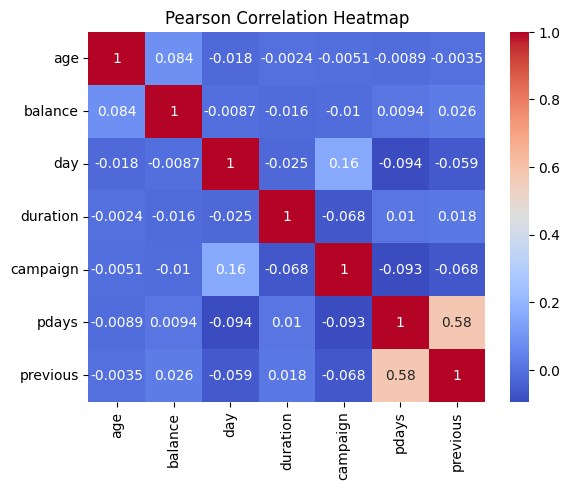

In [19]:
""" 
| Check the correlation between the numerical variables and the target variable 'y' using a correlation matrix. 

"""
bank_copy = bank.filter(['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']).copy()

pearson_corr = bank_copy.corr(method='pearson')
print(pearson_corr)

sns.heatmap(pearson_corr, annot=True, cmap='coolwarm')
plt.title("Pearson Correlation Heatmap")
plt.show()


Q1: 33.000, Q3: 49.000, IQR: 16.000


<Axes: xlabel='age'>

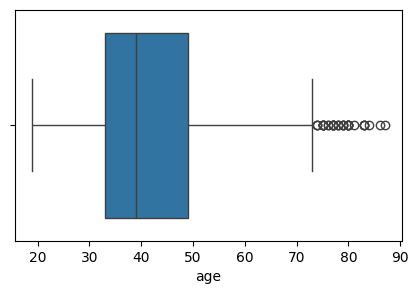

In [20]:
""" 
| Identifying Outliers in Age

"""
Q1 = bank['age'].quantile(0.25)
Q3 = bank['age'].quantile(0.75)
IQR = Q3 - Q1

print(f'Q1: {Q1:.3f}, Q3: {Q3:.3f}, IQR: {IQR:.3f}')
plt.figure(figsize=(5, 3))
sns.boxplot(x=bank['age'])

Q1: 69.000, Q3: 1480.000, IQR: 1411.000


<Axes: xlabel='balance'>

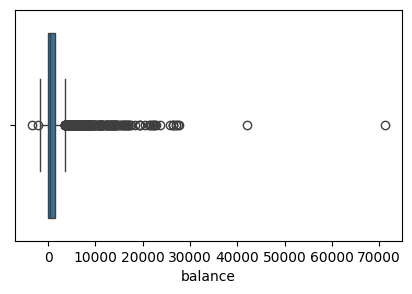

In [21]:
""" 
| Identifying Outliers in Balance 

"""
Q1 = bank['balance'].quantile(0.25)
Q3 = bank['balance'].quantile(0.75)
IQR = Q3 - Q1

print(f'Q1: {Q1:.3f}, Q3: {Q3:.3f}, IQR: {IQR:.3f}')
plt.figure(figsize=(5, 3))
sns.boxplot(x=bank['balance'])

Q1: 104.000, Q3: 329.000, IQR: 225.000


<Axes: xlabel='duration'>

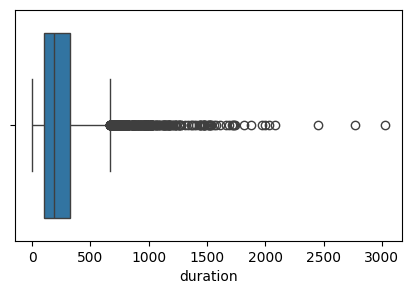

In [22]:
""" 
| Identifying Outliers in Duration 

"""
Q1 = bank['duration'].quantile(0.25)
Q3 = bank['duration'].quantile(0.75)
IQR = Q3 - Q1

print(f'Q1: {Q1:.3f}, Q3: {Q3:.3f}, IQR: {IQR:.3f}')
plt.figure(figsize=(5, 3))
sns.boxplot(x=bank['duration'])

Q1: 1.000, Q3: 3.000, IQR: 2.000


<Axes: xlabel='campaign'>

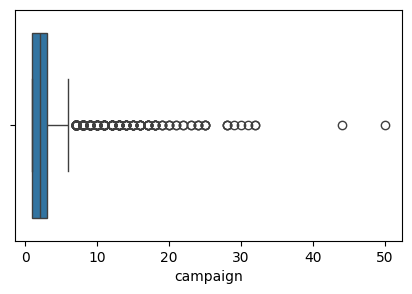

In [23]:
""" 
| Identifying Outliers in Campaign 

"""
Q1 = bank['campaign'].quantile(0.25)
Q3 = bank['campaign'].quantile(0.75)
IQR = Q3 - Q1

print(f'Q1: {Q1:.3f}, Q3: {Q3:.3f}, IQR: {IQR:.3f}')
plt.figure(figsize=(5, 3))
sns.boxplot(x=bank['campaign'])

### **Data Preparation**

Before applying K-Means:

- Drop irrelevant or target columns
- Encode categorical features into numeric format
- Scale numeric features so all are comparable for distance calculations  
- Check that the final dataset has **no missing values** and **all features are numeric**  

In [25]:
"""
| Instead of dropping columns in the original dataset, I will create a copy of the dataset and select only the relevant numerical columns for further analysis. 
| I have chosen the following columns based on what I think is relevant and dropped the duration column due to stated in the description that 
    it should be discarded if a realitic predictive model is needed. Nor is it relevant to know the type of contact, the day and month and the poutcome of the previous campaign.

"""
bank_copy2 = bank.filter(['age', 'balance','campaign', 'pdays', 'previous', 'default', 'housing', 'loan','y']).copy()
bank_copy2.head(4)

,age,balance,campaign,pdays,previous,default,housing,loan,y
0,30,1787,1,-1,0,no,no,no,no
1,33,4789,1,339,4,no,yes,yes,no
2,35,1350,1,330,1,no,yes,no,no
3,30,1476,4,-1,0,no,yes,yes,no


In [ ]:
""" 
| Encoding Categorical Variables using LabelEncoder as it does not expand the dataset 

"""
encoder = LabelEncoder()
bank_copy2['default'] = encoder.fit_transform(bank_copy2['default'])
bank_copy2['housing'] = encoder.fit_transform(bank_copy2['housing'])
bank_copy2['loan'] = encoder.fit_transform(bank_copy2['loan'])
bank_copy2['y'] = encoder.fit_transform(bank_copy2['y'])
bank_copy2.head(4)

,age,balance,campaign,pdays,previous,default,housing,loan,y
0,30,1787,1,-1,0,0,0,0,0
1,33,4789,1,339,4,0,1,1,0
2,35,1350,1,330,1,0,1,0,0
3,30,1476,4,-1,0,0,1,1,0


In [ ]:
""" 
| Scaling Numerical Variables using RobustScaler to handle outliers effectively as we didn't handle outliers above.

"""
scaler = preprocessing.RobustScaler()
bank_scaled = scaler.fit_transform(bank_copy2)
bank_scaled = pd.DataFrame(bank_scaled, columns=bank_copy2.columns)
bank_scaled.head(4)

,age,balance,campaign,pdays,previous,default,housing,loan,y
0,-0.5625,0.951807,-0.5,0.0,0.0,0.0,-1.0,0.0,0.0
1,-0.3750,3.079376,-0.5,340.0,4.0,0.0,0.0,1.0,0.0
2,-0.2500,0.642098,-0.5,331.0,1.0,0.0,0.0,0.0,0.0
3,-0.5625,0.731396,1.0,0.0,0.0,0.0,0.0,1.0,0.0


### **Apply K-Means Clustering**

- Decide an initial number of clusters (K)  
- Fit the K-Means model to your prepared dataset  
- Assign each data point to a cluster

In [31]:
kmeans = KMeans(n_clusters=3, n_init=10, random_state=42)
labels = kmeans.fit_predict(bank_scaled)

centroids = kmeans.cluster_centers_
print("Centroids:\n", kmeans.cluster_centers_)

Centroids:
 [[ 1.31243305e-01  6.58237158e-01  4.77236208e-01  2.54418854e-01
   2.70487413e-02  1.90144617e-02 -4.49919657e-01  1.59614355e-01
   9.31976433e-02]
 [ 4.13629738e-02  5.54700366e-01  7.87172012e-02  3.41008746e+02
   2.88338192e+00  1.45772595e-02 -1.69096210e-01  1.25364431e-01
   1.42857143e-01]
 [ 2.45354730e-01  1.09821639e+00 -3.37837838e-02  1.49527027e+02
   3.06981982e+00  3.46944695e-18 -5.04504505e-01  1.17117117e-01
   2.79279279e-01]]


In [32]:
print(labels[:10])  # show first 10 labels

[0 1 1 0 0 2 1 0 0 2]


### **Choosing the Convenient K**

- Use **Elbow Method**: plot Sum of Squared Distances (SSD) vs K  
- Identify the **elbow point** where SSD reduction slows  
- Calculate **Silhouette scores** to validate K  

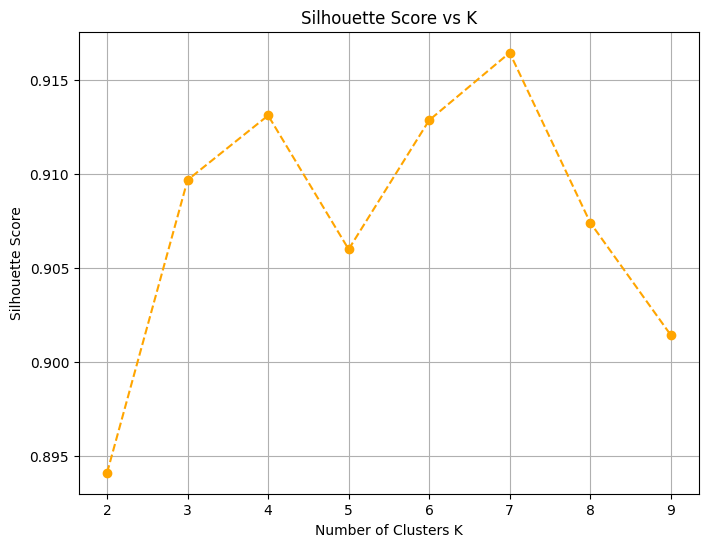

In [35]:
from sklearn.metrics import silhouette_score

sil_scores = []

for k in range(2, 10):
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    # fit K-Means and assign each point to a cluster
    labels = km.fit_predict(bank_scaled)

    # average Silhouette Score for all points
    score = silhouette_score(bank_scaled, labels)

    sil_scores.append(score)

# Plot Silhouette Scores
plt.figure(figsize=(8,6))
plt.plot(range(2,10), sil_scores, 'o--', color='orange')
plt.xlabel("Number of Clusters K")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score vs K")
plt.grid(True)
plt.show()